In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('data/HR_comma_sep.csv')
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
left = df[df.left == 1]
left.shape

(3571, 10)

In [4]:
returned = df[df.left == 0]
returned.shape

(11428, 10)

In [5]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols].groupby(df['left']).mean()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
left,,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.0,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,1.0,0.005321


<Axes: xlabel='salary'>

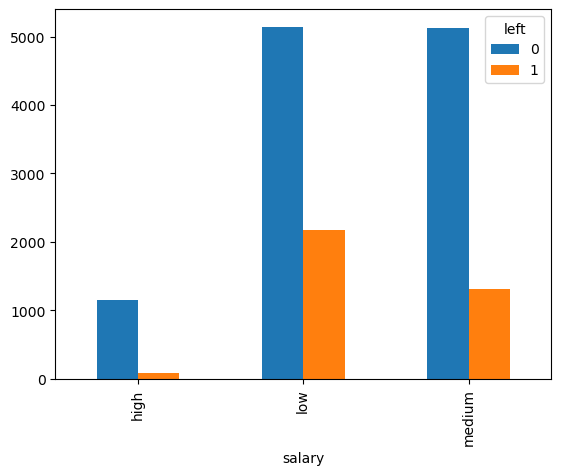

In [6]:
pd.crosstab(df.salary,df.left).plot(kind='bar')

<Axes: xlabel='Department'>

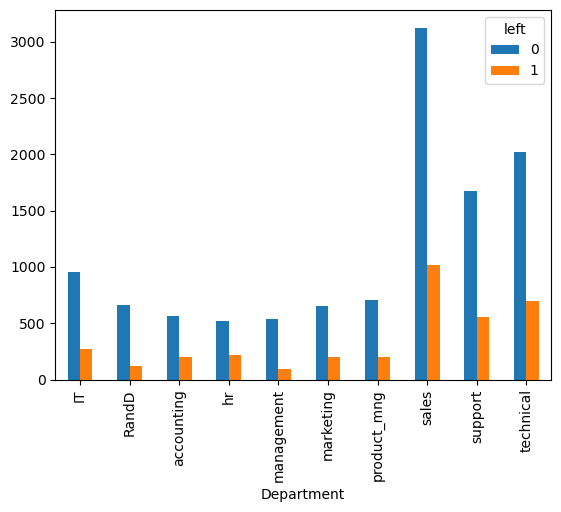

In [7]:
pd.crosstab(df.Department,df.left).plot(kind='bar')

not much changes in the department-wise distribution of employees who left vs those who stayed

## Things affected:
- satisfaction_level	
- average_montly_hours
- promotion_last_5years
- salary

In [8]:
newdf = df[['satisfaction_level','average_montly_hours','promotion_last_5years','salary']]
newdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary
0,0.38,157,0,low
1,0.80,262,0,medium
2,0.11,272,0,medium
3,0.72,223,0,low
4,0.37,159,0,low


In [9]:
sal_dummy = pd.get_dummies(newdf.salary, prefix='salary', dtype=int)
newdf = pd.concat([newdf, sal_dummy], axis=1)
newdf.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,0,low,0,1,0
1,0.80,262,0,medium,0,0,1
2,0.11,272,0,medium,0,0,1
3,0.72,223,0,low,0,1,0
4,0.37,159,0,low,0,1,0


In [10]:
newdf.drop(['salary'], axis=1, inplace=True)

In [11]:
X = newdf
X.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,0,0,1,0
1,0.80,262,0,0,0,1
2,0.11,272,0,0,0,1
3,0.72,223,0,0,1,0
4,0.37,159,0,0,1,0


In [12]:
y = df.left
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7)

In [14]:
X_train.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
3565,0.63,269,0,0,1,0
13936,0.16,286,1,0,0,1
8470,0.71,192,0,0,0,1
12681,0.40,128,0,0,1,0
3885,0.92,149,0,0,0,1


In [15]:
y_train.head()

3565     0
13936    0
8470     0
12681    1
3885     0
Name: left, dtype: int64

In [16]:
X_test.head()

,satisfaction_level,average_montly_hours,promotion_last_5years,salary_high,salary_low,salary_medium
12710,0.64,252,0,0,1,0
943,0.81,235,0,0,1,0
12771,0.10,309,0,0,0,1
1021,0.80,146,0,0,1,0
9884,0.91,235,0,0,1,0


In [17]:
y_test.head()

12710    1
943      1
12771    1
1021     1
9884     0
Name: left, dtype: int64

In [18]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [19]:
model.predict(X_test)

array([0, 0, 1, ..., 0, 0, 0], dtype=int64)

In [20]:
model.score(X_test, y_test)

0.7788888888888889